## Image Processing for the "Laser-sheet second experiment"
### Jasmine JARDRI - UROP (Soft Matter Science & Engineering team, ESPCI-PSL)

#### Required libraries

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from scipy.ndimage import median_filter
from scipy.stats import linregress

In this experiment, we used the same profile extraction method as in the previous experiment (i.e. using the "center of mass" of light intensity) as well as the same "spatial-calibration" script.

In [5]:
def extract_interface_laser(path) : 
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("Unread image :", path)
        return None
    img = cv2.GaussianBlur(img, (5,5), 0)

    height, width = img.shape

    y_profile = []

    for x in range(width):

        col = img[:, x].astype(float)

        if col.max() < 10:
            y_profile.append(np.nan)
            continue

        y = np.arange(height)
        sum_col = np.sum(col)
        if sum_col == 0 : 
            y_profile.append(np.nan) 
            continue

        yc = np.sum(y * col) / np.sum(col)

        y_profile.append(yc)

    y_profile = np.array(y_profile)
    return y_profile



def interface_STACK(basepath, prefixe, nb_images) :  # returns the list of interface positions for each image (i.e. interfaces[i] corresponds to the interface for the image n°i of the stack
    interfaces=[]
    for i in range(1, nb_images+1): 
        filename=f"{prefixe}{i:03d}.jpg"   # Pad i with zeros on the left to make a 3-digit number
        path=basepath + "\\" + filename
        interface=extract_interface_laser(path)
        interfaces.append(interface)
    return interfaces

In [3]:
points = [] # variable to store the clicked points 

# Function called whenever the user clicks on the mouse : 
def click_event(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        points.append((x, y))
        cv2.circle(image, (x, y), 3, (0, 0, 255), -1)
        cv2.imshow("Image", image)
        if len(points) == 2: 
            (x1, y1), (x2, y2) = points

            # Distance between the two click points : 
            distance_pixels = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
            distance_mm = 40 # replace by the real distance between two points you clicked on (50 is for two points separated by 5 cm on the ruler)
            pixel_to_mm = distance_mm / distance_pixels

            # Results : 
            print(f"Point 1 : ({x1}, {y1})")
            print(f"Point 2 : ({x2}, {y2})")
            print(f"Distance en pixels : {distance_pixels:.2f}")
            print(f"1 pixel = {pixel_to_mm:.4f} mm")


# Load and show the ruler-picture : 
image = cv2.imread("C:\\Users\\jajou\\OneDrive\\Documents\\echelle_partie2_exp1.jpg")
cv2.imshow("Image", image)

cv2.setMouseCallback("Image", click_event)
cv2.waitKey(0)
cv2.destroyAllWindows()

Point 1 : (234, 210)
Point 2 : (1176, 198)
Distance en pixels : 942.08
1 pixel = 0.0425 mm


Regarding the amplitude evolution, 3 different methods were tested. Indeed, in this experiment (especially for the "upside-down" part, the laser sometimes reflected a certain way on the SP surface creating a bright spot in the profile of the depression resulting in very noisy curves)

##### 1st METHOD (method of the previous experiment)

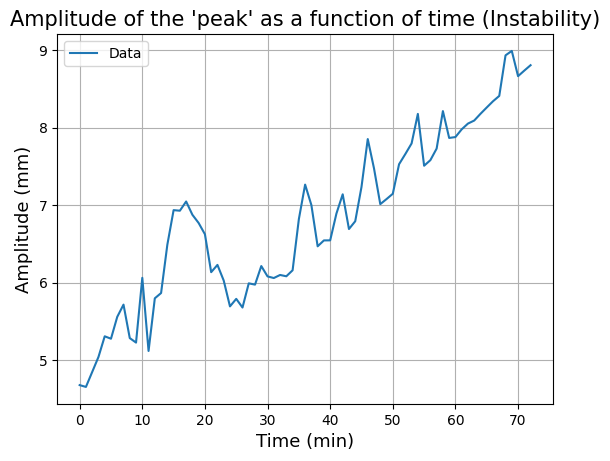

In [ ]:
def Amplitude_STACK_laser_meth1(basepath,prefixe, nb_images, deb, fin, scale) : # returns the list of amplitude for a stack of images (i.e A[i] is a number corresponding to the amplitude of the profile of image n°i)
    A=[]
    interfaces = interface_STACK(basepath, prefixe, nb_images)
    for i in range(nb_images):
        y_data = interfaces[i][deb:fin]
        x_data = np.arange(len(y_data))

        px_to_mm = scale

        x_data_mm = x_data * px_to_mm
        y_data_mm = y_data * px_to_mm 
        ampl = np.nanmax(y_data_mm) - np.nanmin(y_data_mm)
        A.append(ampl)
    return A

# To be adapted to your own data : 
base_path="C:\\Users\\jajou\\OneDrive\\Documents\\CPES\\CPES 2\\Stage_UROP\\Experiences\\Exp2026-06\\Exp2026-06-19\\Exp1_deux_sens\\Img_exp1" # replace by the path of your stack of images
prefixe="Img_exp_" # replace by the prefixe of the images of your stack (for instance here the name of the first image was : Img_exp_001)
nb_images = 73  # replace by the number of images in your stack
begin = 500   # complete the "begin" and "end" variable with the borders of the image area with the peak (determined manually)
end = 1150
px_to_mm = 0.0773  # replace by the value returned by the calibration script (cell above)
A=Amplitude_STACK_laser_meth1(base_path, prefixe, nb_images, deb = begin, fin = end, scale = px_to_mm)


y1_data=np.array(A)
x1_data = np.arange(len(A))


# Plot
fig, ax = plt.subplots()
ax.plot(x1_data,y1_data, label='Data')
ax.set_title("Amplitude of the 'peak' as a function of time (Instability)", fontsize = 15)
ax.set_xlabel("Time (min)", fontsize = 13)
ax.set_ylabel("Amplitude (mm)", fontsize = 13)
ax.grid()
#ax.set_ylim(bottom=0)
ax.legend()
plt.show()

##### 2nd METHOD (using a filter Python function to reduce the noise on the profile before extracting the amplitude)

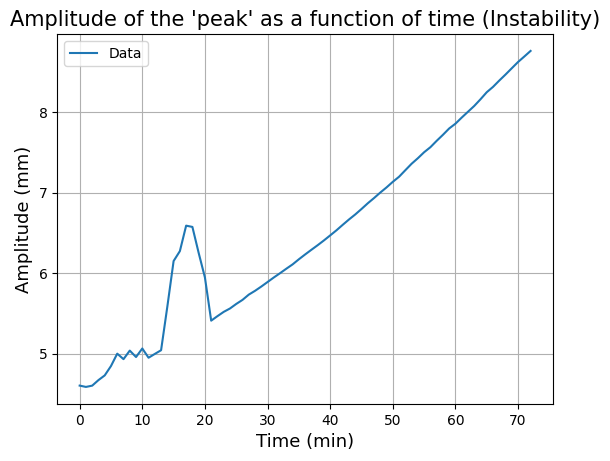

In [7]:
def Amplitude_STACK_laser_meth2(basepath,prefixe, nb_images, deb, fin, scale) : # returns the list of amplitude for a stack of images (i.e A[i] is a number corresponding to the amplitude of the profile of image n°i)
    A=[]
    interfaces = interface_STACK(basepath, prefixe, nb_images)
    for i in range(nb_images):
        y_data = interfaces[i][deb:fin]
        x_data = np.arange(len(y_data))

        px_to_mm = scale

        x_data_mm = x_data * px_to_mm
        y_data_mm = y_data * px_to_mm

        y_filter = median_filter(y_data_mm, size=15)  # filter applied to the profile to smooth it and reduce the noise
        ampl = np.nanmax(y_filter) - np.nanmin(y_filter)
        A.append(ampl)
    return A

# To be adapted to your own data : 
base_path="C:\\Users\\jajou\\OneDrive\\Documents\\CPES\\CPES 2\\Stage_UROP\\Experiences\\Exp2026-06\\Exp2026-06-19\\Exp1_deux_sens\\Img_exp1" # replace by the path of your stack of images
prefixe="Img_exp_" # replace by the prefixe of the images of your stack (for instance here the name of the first image was : Img_exp_001)
nb_images = 73  # replace by the number of images in your stack
begin = 500   # complete the "begin" and "end" variable with the borders of the image area with the peak (determined manually)
end = 1150
px_to_mm = 0.0773  # replace by the value returned by the calibration script (cell above)
A=Amplitude_STACK_laser_meth2(base_path, prefixe, nb_images, deb = begin, fin = end, scale = px_to_mm)



y2_data=np.array(A)
x2_data = np.arange(len(A))


# Plot
fig, ax = plt.subplots()
ax.plot(x2_data,y2_data, label='Data')
ax.set_title("Amplitude of the 'peak' as a function of time (Instability)", fontsize = 15)
ax.set_xlabel("Time (min)", fontsize = 13)
ax.set_ylabel("Amplitude (mm)", fontsize = 13)
ax.grid()
#ax.set_ylim(bottom=0)
ax.legend()
plt.show()

##### 3rd METHOD (using "percentiles" rather than "maximum" and "minimum" values)

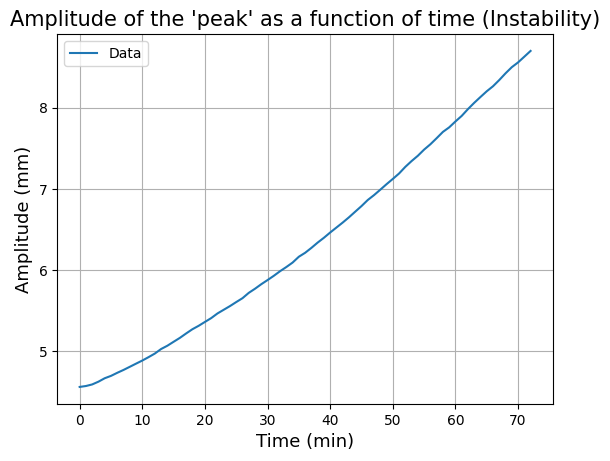

In [8]:
def Amplitude_STACK_laser_meth3(basepath,prefixe, nb_images, deb, fin, scale, perc1, perc2) : # returns the list of amplitude for a stack of images (i.e A[i] is a number corresponding to the amplitude of the profile of image n°i)
    A=[]
    interfaces = interface_STACK(basepath, prefixe, nb_images)
    for i in range(nb_images):
        y_data = interfaces[i][deb:fin]
        x_data = np.arange(len(y_data))

        px_to_mm = scale

        x_data_mm = x_data * px_to_mm
        y_data_mm = y_data * px_to_mm 
        ampl = np.nanpercentile(y_data_mm, perc1) - np.nanpercentile(y_data_mm, perc2)  # adapt the value of perc1 with the correct "threshold" to sufficiantly reduce noise (start at 99 and go down but you should not need to go below 90 ; for some data, it could be more effective to modify the second percentile by starting with 1 and go up to a slightly higher number if needed)
        A.append(ampl)
    return A

# To be adapted to your own data : 
base_path="C:\\Users\\jajou\\OneDrive\\Documents\\CPES\\CPES 2\\Stage_UROP\\Experiences\\Exp2026-06\\Exp2026-06-19\\Exp1_deux_sens\\Img_exp1" # replace by the path of your stack of images
prefixe="Img_exp_" # replace by the prefixe of the images of your stack (for instance here the name of the first image was : Img_exp_001)
nb_images = 73  # replace by the number of images in your stack
begin = 500   # complete the "begin" and "end" variable with the borders of the image area with the peak (determined manually)
end = 1150
px_to_mm = 0.0773  # replace by the value returned by the calibration script (cell above)
perc_max = 96
perc_min = 1
A=Amplitude_STACK_laser_meth3(base_path, prefixe, nb_images, deb = begin, fin = end, scale = px_to_mm, perc1 = perc_max , perc2 = perc_min)


y3_data=np.array(A)
x3_data = np.arange(len(A))


# Plot
fig, ax = plt.subplots()
ax.plot(x3_data,y3_data, label='Data')
ax.set_title("Amplitude of the 'peak' as a function of time (Instability)", fontsize = 15)
ax.set_xlabel("Time (min)", fontsize = 13)
ax.set_ylabel("Amplitude (mm)", fontsize = 13)
ax.grid()
#ax.set_ylim(bottom=0)
ax.legend()
plt.show()

We kept the 3rd method for later analyses because it was more adaptable to each stack thanks to the adjustable "tresholds" in percentiles

The juxtaposition of the instability and stability cases was not a continuous function.  
We normalised each part by its maximum value to ensure continuity at the transition.

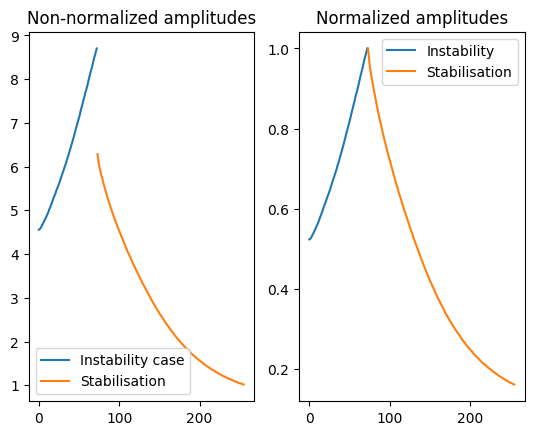

In [9]:
base_path="C:\\Users\\jajou\\OneDrive\\Documents\\CPES\\CPES 2\\Stage_UROP\\Experiences\\Exp2026-06\\Exp2026-06-19\\Exp1_deux_sens\\Img_exp1" # replace by the path of your stack of images
prefixe="Img_exp_" # replace by the prefixe of the images of your stack (for instance here the name of the first image was : Img_exp_001)

#INSTABILITY : 
nb_images = 73  # replace by the number of the last image before the transition in your stack (the next image is usually black)
begin = 500   # complete the "begin" and "end" variable with the borders of the image area with the peak (determined manually)
end = 1150
px_to_mm = 0.0773  # replace by the value returned by the calibration script (cell above)
perc_max = 96
perc_min = 1
A=Amplitude_STACK_laser_meth3(base_path, prefixe, nb_images, deb = begin, fin = end, scale = px_to_mm, perc1 = perc_max, perc2 = perc_min)

y1_data=np.array(A)
x1_data = np.arange(len(A))

# NORMALIZATION : 
maxi1 = y1_data[-1]  # supposed to be the maximum value of the instability part (but in the case of a remaining small peak, we take the last point to ensure continuity)
y1_data_norm = y1_data/maxi1



# STABILISATION : 
nb_images2 = 260   # replace by the total numbler of images in your stack
interfaces2=[]

for i in range(77,nb_images2+1):  # replace all occurrences of "77" in the script by the number of the first image of the second part (the transition usually takes 1-3 images of the stack)
    filename=f"{prefixe}{i:03d}.jpg"
    path=base_path+"\\"+filename
    interface=extract_interface_laser(path)
    interfaces2.append(interface)


# Percentile Method
for i in range(nb_images2-77): 
    y_data = interfaces2[i][475:1200] # replace [475:1200] by the borders of the image area with the peak (determined manually)
    x_data = np.arange(len(y_data)) 

    px_to_mm = 0.0424 ## replace by the value returned by the calibration script (cell above)

    x_data_mm = x_data * px_to_mm
    y_data_mm = y_data * px_to_mm
    
    ampl = np.nanpercentile(y_data_mm, 98) - np.nanpercentile(y_data_mm, 1)  # replace 98 and 1 if necessary (to reduce noise)
    A.append(ampl)


y2_data=np.array(A)
x2_data = np.arange(len(A))

# NORMALIZATION : 
maxi2 = np.max(y2_data[nb_images])
y2_data_norm = y2_data/maxi2

fig, ax = plt.subplots(1,2)
ax[0].plot(x1_data, y1_data, label="Instability case")
ax[0].plot(x2_data[nb_images:], y2_data[nb_images:], label="Stabilisation")
ax[0].set_title("Non-normalized amplitudes")
ax[0].legend()
ax[1].plot(x1_data, y1_data_norm, label="Instability")
ax[1].plot(x2_data[nb_images:], y2_data_norm[nb_images:], label="Stabilisation")
ax[1].set_title("Normalized amplitudes")
ax[1].legend()
plt.show()

Extraction of two characteristic times using the slope (linear regression) on the left and the right sides of the transition between stable and unstable cases

tau1 = 121.60768
tau2 = 76.50653


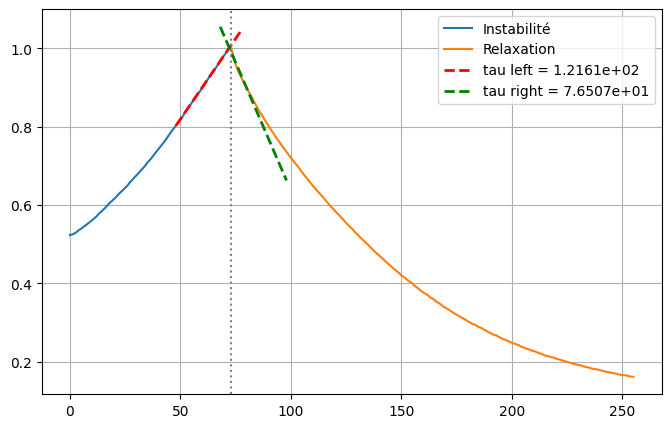

In [11]:
x_break = nb_images
n = 10 # here, adapt the number of points used for the linear regression (on each side of the transition)

# Left adjustment : 
x_g = x1_data[x_break-n:x_break]
y_g = y1_data_norm[x_break-n:x_break]

pente_g, intercept_g, *_ = linregress(x_g, y_g)
x_fit_g = np.linspace(x_break-25, x_break+5, 100)


# Right adjustment : 
x_d = x2_data[x_break:x_break+n]
y_d = y2_data_norm[x_break:x_break+n]

pente_d, intercept_d, *_ = linregress(x_d, y_d)
x_fit_d = np.linspace(x_break-5, x_break+25, 100)


print(f"tau1 = {1/pente_g:.5f}")
print(f"tau2 = {-1/pente_d:.5f}")


# Plot
fig, ax = plt.subplots(figsize=(8,5))

# Data : 
ax.plot(x1_data, y1_data_norm, label="Instabilité")
ax.plot(x2_data[73:], y2_data_norm[73:], label="Relaxation")

# Slopes : 
ax.plot(x_fit_g, pente_g*x_fit_g + intercept_g, linestyle = '--', color = "red", linewidth = 2, label = f'tau left = {1/pente_g:.4e}')
ax.plot(x_fit_d, pente_d*x_fit_d + intercept_d, linestyle = "--", color = "green", linewidth = 2, label = f'tau right = {-1/pente_d:.4e}')

# Break-point position : 
ax.axvline(x_break, color='gray', linestyle=':')

ax.legend()
ax.grid()
plt.show()